In [1]:
# Algorithm name mapping for display
def get_algorithm_display_name(alg):
    """Convert algorithm names to display names for plots and legends"""
    mapping = {
        'ppo_diffusion': 'DifPPO',
        'ql_diffusion': 'DiffQL', 
        'gaussian_ppo': 'PPO',
        'gaussian_dql': 'DQL'
    }
    return mapping.get(alg, alg.replace('_', ' ').title())


Loading metrics from: /home/khanhnq/New-DRL-Memory-Maximize-Problem/logs/gaussian_dql_20260107_131402/training_metrics_12.json
Loading metrics from: /home/khanhnq/New-DRL-Memory-Maximize-Problem/logs/gaussian_dql_20260107_230954/training_metrics_12.json
Loading metrics from: /home/khanhnq/New-DRL-Memory-Maximize-Problem/logs/gaussian_dql_20260107_231721/training_metrics_12.json
Loading metrics from: /home/khanhnq/New-DRL-Memory-Maximize-Problem/logs/gaussian_dql_20260108_114515/training_metrics_12.json
Loading metrics from: /home/khanhnq/New-DRL-Memory-Maximize-Problem/logs/gaussian_dql_20260108_114752/training_metrics_12.json
Loading metrics from: /home/khanhnq/New-DRL-Memory-Maximize-Problem/logs/gaussian_ppo_20260107_131356/training_metrics_12.json
Loading metrics from: /home/khanhnq/New-DRL-Memory-Maximize-Problem/logs/gaussian_ppo_20260107_230942/training_metrics_12.json
Loading metrics from: /home/khanhnq/New-DRL-Memory-Maximize-Problem/logs/gaussian_ppo_20260107_231640/training_

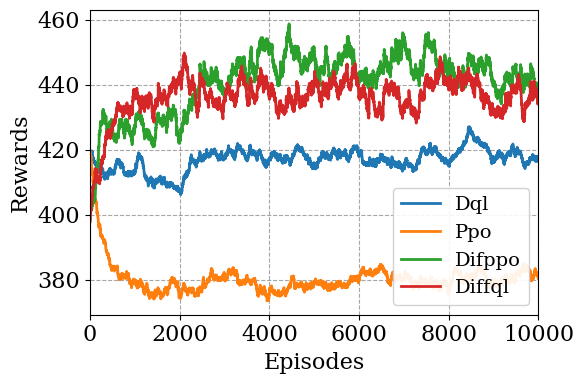

In [19]:
# 6. Statistical Summary Table
import pandas as pd

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
# warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
plt.style.use("default")   # quay về style mặc định (nền trắng)

# set defaults for matplotlib
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định

# Set style for better plots
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")

# Load convergence data
# with open('convergence_data.json', 'r') as f:
#     data = json.load(f)

# print("Available algorithms:", list(data.keys()))
# print("Data structure for each algorithm:")
# for alg, alg_data in data.items():
#     print(f"\n{alg}:")
#     print(f"  Episodes: {len(alg_data['episodes'])}")
#     print(f"  Rewards: {len(alg_data['rewards'])}")
#     if 'losses' in alg_data:
#         print(f"  Losses: {len(alg_data['losses'])}")
#     print(f"  First few rewards: {alg_data['rewards'][:5]}")
#     print(f"  Last few rewards: {alg_data['rewards'][-5:]}")


# Path to logs directory
logs_dir = Path("/home/khanhnq/New-DRL-Memory-Maximize-Problem/logs")

# Collect data from all training runs
training_data = {}

new_keys = ['DiffPPO', 'DiffQL', 'PPO', 'DQL']

for folder in sorted(logs_dir.iterdir()):

    if folder.is_dir():
        metrics_file = folder / "training_metrics_12.json"
        print(f"Loading metrics from: {metrics_file}")
        if metrics_file.exists():
            with open(metrics_file, 'r') as f:
                data = json.load(f)
                if "episode_rewards" in data:
                    training_data[get_algorithm_display_name(folder.name[:-16])] = data["episode_rewards"]
                    # print(f"✓ Loaded {folder.name}: {len(data['episode_rewards'])} episodes")
                else:
                    print(f"✗ No episode_rewards in {folder.name}")
# Create comprehensive statistics table
stats_data = []

for alg, alg_data in training_data.items():
    print(f"Processing statistics for {alg}...")
    rewards = np.array(alg_data)
    
    # Basic statistics
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    min_reward = np.min(rewards)
    max_reward = np.max(rewards)
    median_reward = np.median(rewards)
    
    # Percentiles
    q25 = np.percentile(rewards, 25)
    q75 = np.percentile(rewards, 75)
    
    # Learning progress (first vs last 100 episodes)
    first_100 = np.mean(rewards[:min(100, len(rewards))])
    last_100 = np.mean(rewards[-min(100, len(rewards)):])
    improvement = ((last_100 - first_100) / first_100) * 100
    
    # Convergence analysis (when does it stabilize?)
    window_size = max(20, len(rewards) // 10)
    rolling_std = pd.Series(rewards).rolling(window=window_size, center=True).std()
    convergence_episode = None
    threshold = np.std(rewards) * 0.1  # 10% of total std as convergence threshold
    
    for i, std_val in enumerate(rolling_std):
        if not np.isnan(std_val) and std_val < threshold:
            convergence_episode = i
            break
    
    stats_data.append({
        'Algorithm': get_algorithm_display_name(alg),
        'Mean': f"{mean_reward:.2f}",
        'Std': f"{std_reward:.2f}",
        'Min': f"{min_reward:.2f}",
        'Max': f"{max_reward:.2f}",
        'Median': f"{median_reward:.2f}",
        'Q25': f"{q25:.2f}",
        'Q75': f"{q75:.2f}",
        'First 100': f"{first_100:.2f}",
        'Last 100': f"{last_100:.2f}",
        'Improvement %': f"{improvement:.1f}%",
        'Convergence Episode': f"{convergence_episode if convergence_episode else 'N/A'}"
    })

# Create and display DataFrame
df_stats = pd.DataFrame(stats_data)
print("📊 COMPREHENSIVE STATISTICAL ANALYSIS")
print("=" * 80)
print(df_stats.to_string(index=False))
print("=" * 80)

def ema(x, alpha=0.005):
    y = np.zeros_like(x, dtype=float)
    y[0] = x[0]
    for t in range(1, len(x)):
        y[t] = alpha*x[t] + (1-alpha)*y[t-1]
    return y


plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
# plot convergence curves

# plt.figure(figsize=(10, 8))
for alg, rewards in training_data.items():
    plt.plot(ema(rewards), label=get_algorithm_display_name(alg))    
plt.xlabel("Episodes")
plt.ylabel("Rewards")
plt.legend()
plt.xlim(0, 10000)
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
user_counts = [8,10,12]
algorithms = new_keys

In [23]:
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

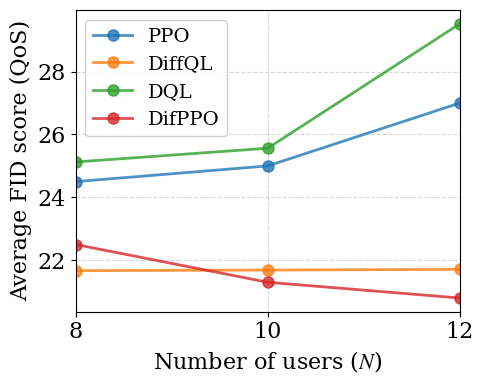

In [ ]:

# # 1. Average QoS vs User Count
# ax1 = axes[0]
for i, alg in enumerate(algorithms):
    pass

plt.xlabel(r'Number of users ($N$)')
plt.ylabel(r'Average FID score (QoS)')
# plt.title('Average QoS vs User Count', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(user_counts)
plt.xlim(8, 12)

plt.tight_layout()
plt.savefig('avg_qos.png', dpi=300)
# plt.suptitle('QoS Analysis Across User Counts', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [ ]:
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

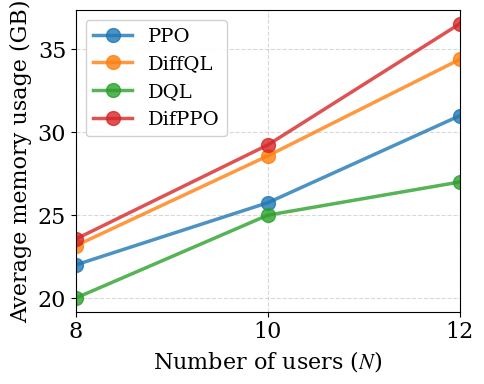

In [ ]:
# 11. Memory Usage Analysis Across User Counts
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# axes = axes.flatten()
# 1. Average Memory vs User Count
# ax1 = axes[0]
for i, alg in enumerate(algorithms):
    pass

plt.xlabel(r'Number of users ($N$)')
plt.ylabel(r'Average memory usage (GB)')
# plt.title('Average Memory Usage vs User Count', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim(8, 12)
plt.legend()
plt.xticks(user_counts)

plt.tight_layout()
# plt.suptitle('Memory Usage Analysis Across User Counts', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('avg_memory.png', dpi=300, bbox_inches='tight')
plt.show()


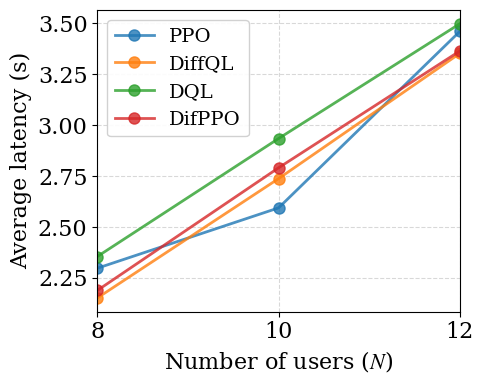

In [ ]:
# 12. Latency Analysis Across User Counts
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# axes = axes.flatten()

# 1. Average Latency vs User Count
# ax1 = axes[0]
for i, alg in enumerate(algorithms):
    pass
plt.xlabel(r'Number of users ($N$)')
plt.ylabel(r'Average latency (s)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(user_counts)
plt.xlim(8, 12)


plt.tight_layout()
# plt.suptitle('Latency Analysis Across User Counts', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('avg_latency.png')
plt.show()


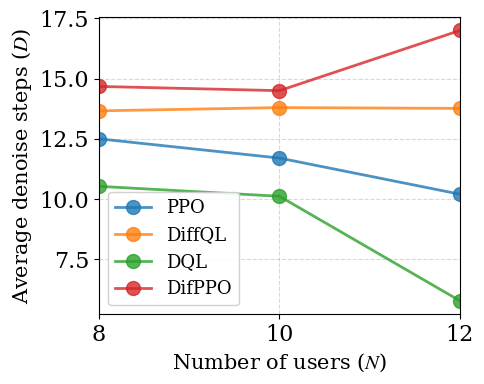

In [ ]:
# 14. Denoise Steps Analysis Across User Counts
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# axes = axes.flatten()



for i, alg in enumerate(algorithms):
    pass

plt.xlabel(r'Number of users ($N$)', fontsize=15)
plt.ylabel(r'Average denoise steps ($D$)', fontsize=15)
# plt.title('Average Denoise Steps vs User Count', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=13)
plt.xticks(user_counts)
plt.xlim(8, 12)
plt.tight_layout()
plt.savefig('avg_denoise.png', dpi=300)
plt.show()
